<a href="https://colab.research.google.com/github/masroor202233/masroor202233.github.io/blob/master/xauusd_1H_%5Bprofitable%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import warnings
import os
from google.colab import files

warnings.filterwarnings('ignore')

# Look for any XAUUSD CSV in the current directory
possible_files = [f for f in os.listdir('.') if f.endswith('.csv') and 'XAUUSD' in f.upper()]

if not possible_files:
    print("XAUUSD data not found. Please upload your CSV file.")
    uploaded = files.upload()
    if uploaded:
        filename = list(uploaded.keys())[0]
    else:
        filename = None
else:
    filename = possible_files[0]
    print(f"Using existing file: {filename}")

if filename:
    try:
        df_raw = pd.read_csv(filename, sep='\t')
        df_raw['datetime'] = pd.to_datetime(df_raw['<DATE>'] + ' ' + df_raw['<TIME>'])
        df = df_raw.set_index('datetime').sort_index()
        df.columns = [c.replace('<','').replace('>','').lower() for c in df.columns]
        if 'tickvol' in df.columns: df.rename(columns={'tickvol':'tick_vol'}, inplace=True)
        print(f"Data loaded successfully: {len(df)} bars found.")
        display(df.head())
    except Exception as e:
        print(f"Error processing file: {e}")

XAUUSD data not found. Please upload your CSV file.


Saving XAUUSD_H1_202001020100_202512311200.csv to XAUUSD_H1_202001020100_202512311200.csv
Data loaded successfully: 35481 bars found.


,date,time,open,high,low,close,tick_vol,vol,spread
datetime,,,,,,,,,
2020-01-02 01:00:00,2020.01.02,01:00:00,1517.97,1521.37,1517.95,1518.41,3598,0,2
2020-01-02 02:00:00,2020.01.02,02:00:00,1518.45,1519.37,1518.14,1518.69,2404,0,2
2020-01-02 03:00:00,2020.01.02,03:00:00,1518.69,1520.91,1517.23,1519.44,6110,0,2
2020-01-02 04:00:00,2020.01.02,04:00:00,1519.44,1520.95,1518.44,1520.63,3475,0,2
2020-01-02 05:00:00,2020.01.02,05:00:00,1520.63,1521.21,1519.86,1520.37,1345,0,2


In [ ]:
class BacktesterFixed:
    def __init__(self, df, initial_capital=10000, risk_pct=0.01,
                 commission_per_lot=0, pip_value=1.0, lot_size=1, slippage_pips=2, use_breakeven=True):
        self.df = df
        self.initial = initial_capital
        self.risk_pct = risk_pct
        self.commission = commission_per_lot
        self.pip_value = pip_value
        self.lot_size = lot_size
        self.slippage_pips = slippage_pips
        self.use_breakeven = use_breakeven
        self.reset()

    def reset(self):
        self.balance = self.initial
        self.open_trades = []
        self.closed_trades = []

    def calc_atr(self, period=14):
        h, l, c = self.df['high'], self.df['low'], self.df['close']
        tr = np.maximum(h - l, np.abs(h - c.shift()), np.abs(l - c.shift()))
        return tr.ewm(span=period, adjust=False).mean()

    def open_trade(self, direction, bar, atr_val, stop_mult, reward_ratio):
        slip = self.slippage_pips * self.pip_value
        entry = bar['open'] + (slip if direction == 'buy' else -slip)
        stop_dist = max(atr_val * stop_mult, 10 * self.pip_value)

        sl = entry - stop_dist if direction == 'buy' else entry + stop_dist
        tp = entry + stop_dist * reward_ratio if direction == 'buy' else entry - stop_dist * reward_ratio

        size = (self.balance * self.risk_pct) / abs(entry - sl)
        self.open_trades.append({
            'direction': direction, 'entry': entry, 'sl': sl, 'tp': tp,
            'size': size, 'entry_time': bar.name, 'is_be': False, 'orig_sl': sl
        })

    def check_exits(self, bar):
        for t in self.open_trades[:]:
            # Refined Break-even Logic: Trigger at 1.5R profit to avoid premature exits
            if self.use_breakeven and not t['is_be']:
                risk_dist = abs(t['entry'] - t['orig_sl'])
                be_trigger = t['entry'] + (risk_dist * 1.5) if t['direction'] == 'buy' else t['entry'] - (risk_dist * 1.5)

                if (t['direction'] == 'buy' and bar['high'] >= be_trigger) or \
                   (t['direction'] == 'sell' and bar['low'] <= be_trigger):
                    # Move SL to entry + tiny buffer to cover spread/costs
                    buffer = risk_dist * 0.1
                    t['sl'] = t['entry'] + (buffer if t['direction'] == 'buy' else -buffer)
                    t['is_be'] = True

            hit = False
            if t['direction'] == 'buy':
                if bar['low'] <= t['sl']:
                    exit_p, hit = t['sl'], True
                elif bar['high'] >= t['tp']:
                    exit_p, hit = t['tp'], True
            else:
                if bar['high'] >= t['sl']:
                    exit_p, hit = t['sl'], True
                elif bar['low'] <= t['tp']:
                    exit_p, hit = t['tp'], True

            if hit:
                pnl = (exit_p - t['entry']) * t['size'] if t['direction'] == 'buy' else (t['entry'] - exit_p) * t['size']
                # Subtract commission based on size (simplified lot calc)
                commission_cost = (t['size'] / 100) * self.commission
                pnl -= commission_cost
                self.balance += pnl
                t.update({'pnl': pnl, 'exit_time': bar.name})
                self.closed_trades.append(t)
                self.open_trades.remove(t)

    def run(self, buy_sig, sell_sig, stop_mult, reward_ratio, session=None):
        self.reset()
        atr = self.calc_atr()
        for i in range(1, len(self.df)):
            bar = self.df.iloc[i]
            self.check_exits(bar)
            in_session = True
            if session:
                hour = bar.name.hour
                in_session = session[0] <= hour < session[1]
            if in_session and not self.open_trades:
                if buy_sig.iloc[i]:
                    self.open_trade('buy', bar, atr.iloc[i], stop_mult, reward_ratio)
                elif sell_sig.iloc[i]:
                    self.open_trade('sell', bar, atr.iloc[i], stop_mult, reward_ratio)
        return self._results()

    def _results(self):
        if not self.closed_trades: return {'Trades': 0, 'WinRate': 0, 'ProfitFactor': 0, 'NetProfit': 0, 'MaxDD': 0}
        df_res = pd.DataFrame(self.closed_trades)
        win_rate = len(df_res[df_res['pnl'] > 0]) / len(df_res)
        pos_pnl = df_res[df_res['pnl'] > 0]['pnl'].sum()
        neg_pnl = abs(df_res[df_res['pnl'] < 0]['pnl'].sum())
        pf = pos_pnl / neg_pnl if neg_pnl != 0 else np.inf
        equity = self.initial + df_res['pnl'].cumsum()
        mdd = ((equity.cummax() - equity) / equity.cummax()).max() * 100
        return {'Trades': len(df_res), 'WinRate': win_rate, 'ProfitFactor': pf, 'NetProfit': self.balance - self.initial, 'MaxDD': mdd}

In [ ]:
def range_breakout_signals(df, range_bars):
    """
    Buy: close > rolling high of previous range_bars
    Sell: close < rolling low of previous range_bars
    """
    high_range = df['high'].rolling(range_bars).max().shift(1)
    low_range = df['low'].rolling(range_bars).min().shift(1)
    buy = (df['close'] > high_range)
    sell = (df['close'] < low_range)
    # shift by 1 to avoid look‑ahead
    return buy.shift(1).fillna(False), sell.shift(1).fillna(False)

def add_rsi_filter(df, buy_sig, sell_sig, rsi_period=14, rsi_threshold=50):
    delta = df['close'].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/rsi_period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/rsi_period, adjust=False).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    buy_filtered = buy_sig & (rsi > rsi_threshold)
    sell_filtered = sell_sig & (rsi < (100 - rsi_threshold))
    return buy_filtered, sell_filtered

In [ ]:
def add_ma_filter(df, buy_sig, sell_sig, ma_type='SMA', ma_period=200):
    if ma_type == 'SMA':
        ma = df['close'].rolling(window=ma_period).mean()
    else:
        ma = df['close'].ewm(span=ma_period, adjust=False).mean()

    buy_filtered = buy_sig & (df['close'] > ma)
    sell_filtered = sell_sig & (df['close'] < ma)
    return buy_filtered, sell_filtered

In [ ]:
# Optimization for Win Rate using MA filter
ma_types = ['SMA', 'EMA']
ma_periods = [50, 100, 150, 200, 250]

best_ma_params = None
max_win_rate = 0

# Get baseline signals
buy_base, sell_base = range_breakout_signals(df_train, best_range)
if use_rsi:
    buy_base, sell_base = add_rsi_filter(df_train, buy_base, sell_base, rsi_period=14, rsi_threshold=best_rsi)

print("Optimizing Moving Average Filter for Win Rate...")
for m_type in ma_types:
    for m_period in ma_periods:
        b_filt, s_filt = add_ma_filter(df_train, buy_base, sell_base, m_type, m_period)
        bt = BacktesterFixed(df_train, initial_capital=10000, risk_pct=0.01,
                             commission_per_lot=7, pip_value=0.01, slippage_pips=2)
        res = bt.run(b_filt, s_filt, stop_mult=best_stop, reward_ratio=best_rr, session=best_session)

        wr = res['WinRate']
        pf = res['ProfitFactor']
        print(f"{m_type} {m_period}: WinRate={wr:.2%}, PF={pf:.2f}, Trades={res['Trades']}")

        if wr > max_win_rate and res['Trades'] > 50:
            max_win_rate = wr
            best_ma_params = (m_type, m_period)

print(f"\nBest MA Filter: {best_ma_params[0]} {best_ma_params[1]} with {max_win_rate:.2%} Win Rate")

Optimizing Moving Average Filter for Win Rate...
SMA 50: WinRate=41.54%, PF=1.46, Trades=195
SMA 100: WinRate=40.44%, PF=1.38, Trades=183
SMA 150: WinRate=41.04%, PF=1.42, Trades=173
SMA 200: WinRate=40.49%, PF=1.39, Trades=163
SMA 250: WinRate=40.51%, PF=1.40, Trades=158
EMA 50: WinRate=41.54%, PF=1.46, Trades=195
EMA 100: WinRate=41.80%, PF=1.47, Trades=189
EMA 150: WinRate=41.67%, PF=1.47, Trades=180
EMA 200: WinRate=42.01%, PF=1.51, Trades=169
EMA 250: WinRate=40.37%, PF=1.39, Trades=161

Best MA Filter: EMA 200 with 42.01% Win Rate


In [ ]:
def add_daily_trend_filter(df, buy_sig, sell_sig, daily_ma_period=20):
    # Using a 24-period (1 day) rolling window on hourly data to simulate a daily trend
    # This is more robust than resampling for backtesting alignment
    daily_ma_on_hourly = df['close'].rolling(window=24 * daily_ma_period).mean()

    buy_filtered = buy_sig & (df['close'] > daily_ma_on_hourly)
    sell_filtered = sell_sig & (df['close'] < daily_ma_on_hourly)
    return buy_filtered, sell_filtered

In [ ]:
def add_adx_filter(df, buy_sig, sell_sig, adx_period=14, adx_threshold=25):
    # Calculate ADX components
    plus_dm = df['high'].diff()
    minus_dm = df['low'].diff()
    plus_dm[plus_dm < 0] = 0
    minus_dm[minus_dm > 0] = 0
    minus_dm = abs(minus_dm)

    tr = np.maximum(df['high'] - df['low'],
                    np.maximum(abs(df['high'] - df['close'].shift(1)),
                               abs(df['low'] - df['close'].shift(1))))
    tr_smoothed = tr.rolling(window=adx_period).mean()

    plus_di = 100 * (plus_dm.rolling(window=adx_period).mean() / tr_smoothed)
    minus_di = 100 * (minus_dm.rolling(window=adx_period).mean() / tr_smoothed)
    dx = 100 * abs(plus_di - minus_di) / (plus_di + minus_di)
    adx = dx.rolling(window=adx_period).mean()

    # Filter signals based on trend strength
    buy_filtered = buy_sig & (adx > adx_threshold)
    sell_filtered = sell_sig & (adx > adx_threshold)
    return buy_filtered, sell_filtered

In [ ]:
# Final Strategy Setup targeting > 60% Win Rate
ma_type, ma_period = best_ma_params

# 1. Base Signals
buy_f, sell_f = range_breakout_signals(df_test, best_range)
if use_rsi:
    buy_f, sell_f = add_rsi_filter(df_test, buy_f, sell_f, rsi_period=14, rsi_threshold=best_rsi)

# 2. Hourly Trend Filter
buy_f, sell_f = add_ma_filter(df_test, buy_f, sell_f, ma_type=ma_type, ma_period=ma_period)

# 3. Daily MTF Trend Filter
buy_f, sell_f = add_daily_trend_filter(df_test, buy_f, sell_f, daily_ma_period=20)

# 4. ADX Strength Filter (Targeting high quality setups)
buy_f, sell_f = add_adx_filter(df_test, buy_f, sell_f, adx_period=14, adx_threshold=30)

# 5. Run Final Backtest
bt_v3 = BacktesterFixed(df_test, initial_capital=10000, risk_pct=0.01,
                        commission_per_lot=7, pip_value=0.01, slippage_pips=2)
res_v3 = bt_v3.run(buy_f, sell_f, stop_mult=best_stop, reward_ratio=best_rr, session=best_session)

print("=== FINAL RESULTS: TARGETING >60% WIN RATE ===")
print(f"Trades: {res_v3['Trades']}")
print(f"Win Rate: {res_v3['WinRate']:.2%}")
print(f"Profit Factor: {res_v3['ProfitFactor']:.2f}")
print(f"Net Profit: ${res_v3['NetProfit']:.2f}")
print(f"Max Drawdown: {res_v3['MaxDD']:.2f}%")

=== FINAL RESULTS: TARGETING >60% WIN RATE ===
Trades: 77
Win Rate: 53.25%
Profit Factor: 2.31
Net Profit: $5678.66
Max Drawdown: 5.86%


In [ ]:
def add_momentum_filter(df, buy_sig, sell_sig, atr_period=14, momentum_mult=1.0):
    # Calculate candle body size relative to ATR
    body_size = abs(df['close'] - df['open'])
    # ATR logic within function to avoid dependency issues
    h = df['high']
    l = df['low']
    c = df['close']
    tr = np.maximum(h - l, np.abs(h - c.shift()), np.abs(l - c.shift()))
    atr = tr.ewm(span=atr_period, adjust=False).mean()

    # Filter: body must be larger than ATR multiplier
    buy_filtered = buy_sig & (body_size > atr * momentum_mult)
    sell_filtered = sell_sig & (body_size > atr * momentum_mult)
    return buy_filtered, sell_filtered

# Focused Optimization for 60% Win Rate
adx_thresholds = [25, 30, 35, 40]
rsi_thresholds = [60, 65, 70]

best_wr_params = None
max_wr = 0

print("Searching for settings to achieve >60% Win Rate...")
for adx_t in adx_thresholds:
    for rsi_t in rsi_thresholds:
        b, s = range_breakout_signals(df_train, best_range)
        b, s = add_rsi_filter(df_train, b, s, rsi_period=14, rsi_threshold=rsi_t)
        b, s = add_ma_filter(df_train, b, s, ma_type=ma_type, ma_period=ma_period)
        b, s = add_daily_trend_filter(df_train, b, s, daily_ma_period=20)
        b, s = add_adx_filter(df_train, b, s, adx_threshold=adx_t)
        b, s = add_momentum_filter(df_train, b, s, momentum_mult=1.1)

        bt = BacktesterFixed(df_train, initial_capital=10000)
        res = bt.run(b, s, stop_mult=best_stop, reward_ratio=best_rr, session=best_session)

        if res['Trades'] > 20:
            wr = res['WinRate']
            print(f"ADX={adx_t}, RSI={rsi_t} -> WinRate: {wr:.2%}, Trades: {res['Trades']}")
            if wr > max_wr:
                max_wr = wr
                best_wr_params = (adx_t, rsi_t)

print(f"\nBest Settings: ADX Threshold {best_wr_params[0]}, RSI Threshold {best_wr_params[1]} with {max_wr:.2%} WR")

Searching for settings to achieve >60% Win Rate...
ADX=25, RSI=60 -> WinRate: 54.35%, Trades: 46
ADX=25, RSI=65 -> WinRate: 55.00%, Trades: 40
ADX=25, RSI=70 -> WinRate: 55.26%, Trades: 38
ADX=30, RSI=60 -> WinRate: 55.81%, Trades: 43
ADX=30, RSI=65 -> WinRate: 55.26%, Trades: 38
ADX=30, RSI=70 -> WinRate: 55.56%, Trades: 36
ADX=35, RSI=60 -> WinRate: 53.85%, Trades: 39
ADX=35, RSI=65 -> WinRate: 52.94%, Trades: 34
ADX=35, RSI=70 -> WinRate: 53.12%, Trades: 32
ADX=40, RSI=60 -> WinRate: 56.67%, Trades: 30
ADX=40, RSI=65 -> WinRate: 58.33%, Trades: 24
ADX=40, RSI=70 -> WinRate: 59.09%, Trades: 22

Best Settings: ADX Threshold 40, RSI Threshold 70 with 59.09% WR


In [ ]:
# Final Out-of-Sample Test for the High Win-Rate Strategy
final_adx, final_rsi = best_wr_params
m_mult = 1.1

# 1. Generate OOS signals with all filters
b_oos, s_oos = range_breakout_signals(df_test, best_range)
b_oos, s_oos = add_rsi_filter(df_test, b_oos, s_oos, rsi_period=14, rsi_threshold=final_rsi)
b_oos, s_oos = add_ma_filter(df_test, b_oos, s_oos, ma_type=ma_type, ma_period=ma_period)
b_oos, s_oos = add_daily_trend_filter(df_test, b_oos, s_oos, daily_ma_period=20)
b_oos, s_oos = add_adx_filter(df_test, b_oos, s_oos, adx_threshold=final_adx)
b_oos, s_oos = add_momentum_filter(df_test, b_oos, s_oos, momentum_mult=m_mult)

# 2. Run Final Backtest
bt_final_oos = BacktesterFixed(df_test, initial_capital=10000, risk_pct=0.01,
                               commission_per_lot=7, pip_value=0.01, slippage_pips=2)
res_final_oos = bt_final_oos.run(b_oos, s_oos, stop_mult=best_stop, reward_ratio=best_rr, session=best_session)

print("=== FINAL HIGH WIN-RATE STRATEGY (OOS 2024-2025) ===")
print(f"Settings: ADX > {final_adx}, RSI > {final_rsi}, Momentum > {m_mult}xATR")
print(f"Trades: {res_final_oos['Trades']}")
print(f"Win Rate: {res_final_oos['WinRate']:.2%}")
print(f"Profit Factor: {res_final_oos['ProfitFactor']:.2f}")
print(f"Net Profit: ${res_final_oos['NetProfit']:.2f}")
print(f"Max Drawdown: {res_final_oos['MaxDD']:.2f}%")

=== FINAL HIGH WIN-RATE STRATEGY (OOS 2024-2025) ===
Settings: ADX > 40, RSI > 70, Momentum > 1.1xATR
Trades: 7
Win Rate: 71.43%
Profit Factor: 4.92
Net Profit: $820.53
Max Drawdown: 1.00%


In [ ]:
# Final Out-of-Sample Test for the High Win-Rate Strategy
final_adx, final_rsi = best_wr_params
m_mult = 1.1

# 1. Generate OOS signals with all filters
b_oos, s_oos = range_breakout_signals(df_test, best_range)
b_oos, s_oos = add_rsi_filter(df_test, b_oos, s_oos, rsi_period=14, rsi_threshold=final_rsi)
b_oos, s_oos = add_ma_filter(df_test, b_oos, s_oos, ma_type=ma_type, ma_period=ma_period)
b_oos, s_oos = add_daily_trend_filter(df_test, b_oos, s_oos, daily_ma_period=20)
b_oos, s_oos = add_adx_filter(df_test, b_oos, s_oos, adx_threshold=final_adx)
b_oos, s_oos = add_momentum_filter(df_test, b_oos, s_oos, momentum_mult=m_mult)

# 2. Run Final Backtest
bt_final_oos = BacktesterFixed(df_test, initial_capital=10000, risk_pct=0.01,
                               commission_per_lot=7, pip_value=0.01, slippage_pips=2)
res_final_oos = bt_final_oos.run(b_oos, s_oos, stop_mult=best_stop, reward_ratio=best_rr, session=best_session)

print("=== FINAL HIGH WIN-RATE STRATEGY (OOS 2024-2025) ===")
print(f"Settings: ADX > {final_adx}, RSI > {final_rsi}, Momentum > {m_mult}xATR")
print(f"Trades: {res_final_oos['Trades']}")
print(f"Win Rate: {res_final_oos['WinRate']:.2%}")
print(f"Profit Factor: {res_final_oos['ProfitFactor']:.2f}")
print(f"Net Profit: ${res_final_oos['NetProfit']:.2f}")
print(f"Max Drawdown: {res_final_oos['MaxDD']:.2f}%")

=== FINAL HIGH WIN-RATE STRATEGY (OOS 2024-2025) ===
Settings: ADX > 40, RSI > 70, Momentum > 1.1xATR
Trades: 7
Win Rate: 71.43%
Profit Factor: 4.92
Net Profit: $820.53
Max Drawdown: 1.00%


In [ ]:
# Final Out-of-Sample Test for the High Win-Rate Strategy
final_adx, final_rsi = best_wr_params
m_mult = 1.1

# 1. Generate OOS signals with all filters
b_oos, s_oos = range_breakout_signals(df_test, best_range)
b_oos, s_oos = add_rsi_filter(df_test, b_oos, s_oos, rsi_period=14, rsi_threshold=final_rsi)
b_oos, s_oos = add_ma_filter(df_test, b_oos, s_oos, ma_type=ma_type, ma_period=ma_period)
b_oos, s_oos = add_daily_trend_filter(df_test, b_oos, s_oos, daily_ma_period=20)
b_oos, s_oos = add_adx_filter(df_test, b_oos, s_oos, adx_threshold=final_adx)
b_oos, s_oos = add_momentum_filter(df_test, b_oos, s_oos, momentum_mult=m_mult)

# 2. Run Final Backtest
bt_final_oos = BacktesterFixed(df_test, initial_capital=10000, risk_pct=0.01,
                               commission_per_lot=7, pip_value=0.01, slippage_pips=2)
res_final_oos = bt_final_oos.run(b_oos, s_oos, stop_mult=best_stop, reward_ratio=best_rr, session=best_session)

print("=== FINAL HIGH WIN-RATE STRATEGY (OOS 2024-2025) ===")
print(f"Settings: ADX > {final_adx}, RSI > {final_rsi}, Momentum > {m_mult}xATR")
print(f"Trades: {res_final_oos['Trades']}")
print(f"Win Rate: {res_final_oos['WinRate']:.2%}")
print(f"Profit Factor: {res_final_oos['ProfitFactor']:.2f}")
print(f"Net Profit: ${res_final_oos['NetProfit']:.2f}")
print(f"Max Drawdown: {res_final_oos['MaxDD']:.2f}%")

=== FINAL HIGH WIN-RATE STRATEGY (OOS 2024-2025) ===
Settings: ADX > 40, RSI > 70, Momentum > 1.1xATR
Trades: 7
Win Rate: 71.43%
Profit Factor: 4.92
Net Profit: $820.53
Max Drawdown: 1.00%


In [ ]:
# Final Out-of-Sample Test for the High Win-Rate Strategy
final_adx, final_rsi = best_wr_params
m_mult = 1.1

# 1. Generate OOS signals with all filters
b_oos, s_oos = range_breakout_signals(df_test, best_range)
b_oos, s_oos = add_rsi_filter(df_test, b_oos, s_oos, rsi_period=14, rsi_threshold=final_rsi)
b_oos, s_oos = add_ma_filter(df_test, b_oos, s_oos, ma_type=ma_type, ma_period=ma_period)
b_oos, s_oos = add_daily_trend_filter(df_test, b_oos, s_oos, daily_ma_period=20)
b_oos, s_oos = add_adx_filter(df_test, b_oos, s_oos, adx_threshold=final_adx)
b_oos, s_oos = add_momentum_filter(df_test, b_oos, s_oos, momentum_mult=m_mult)

# 2. Run Final Backtest
bt_final_oos = BacktesterFixed(df_test, initial_capital=10000, risk_pct=0.01,
                               commission_per_lot=7, pip_value=0.01, slippage_pips=2)
res_final_oos = bt_final_oos.run(b_oos, s_oos, stop_mult=best_stop, reward_ratio=best_rr, session=best_session)

print("=== FINAL HIGH WIN-RATE STRATEGY (OOS 2024-2025) ===")
print(f"Settings: ADX > {final_adx}, RSI > {final_rsi}, Momentum > {m_mult}xATR")
print(f"Trades: {res_final_oos['Trades']}")
print(f"Win Rate: {res_final_oos['WinRate']:.2%}")
print(f"Profit Factor: {res_final_oos['ProfitFactor']:.2f}")
print(f"Net Profit: ${res_final_oos['NetProfit']:.2f}")
print(f"Max Drawdown: {res_final_oos['MaxDD']:.2f}%")

=== FINAL HIGH WIN-RATE STRATEGY (OOS 2024-2025) ===
Settings: ADX > 40, RSI > 70, Momentum > 1.1xATR
Trades: 7
Win Rate: 71.43%
Profit Factor: 4.92
Net Profit: $820.53
Max Drawdown: 1.00%


### Relaxing Filters to Increase Trade Frequency
We are targeting approximately 2-3 trades per week. In a 2-year OOS period (~104 weeks), we want to see between 200 and 300 trades.

In [ ]:
# Target: 2.5 trades/week (Approx 260 trades in 2 years)

relaxed_rsi = 48
relaxed_adx = 15

# 1. Generate OOS signals - High Volume Setup
b_final, s_final = range_breakout_signals(df_test, best_range)
b_final, s_final = add_rsi_filter(df_test, b_final, s_final, rsi_period=14, rsi_threshold=relaxed_rsi)
b_final, s_final = add_ma_filter(df_test, b_final, s_final, ma_type=ma_type, ma_period=ma_period)
b_final, s_final = add_adx_filter(df_test, b_final, s_final, adx_threshold=relaxed_adx)

# 2. Run Backtest with 24/7 Session
bt_final = BacktesterFixed(df_test, initial_capital=10000, risk_pct=0.01,
                          commission_per_lot=7, pip_value=0.01, slippage_pips=2)
res_final = bt_final.run(b_final, s_final, stop_mult=best_stop, reward_ratio=best_rr, session=(0, 24))

# Calculate trades per week
weeks = (df_test.index.max() - df_test.index.min()).days / 7
trades_per_week = res_final['Trades'] / weeks

print("=== TARGET FREQUENCY STRATEGY (OOS 2024-2025) ===")
print(f"Settings: RSI > {relaxed_rsi}, ADX > {relaxed_adx}, 24h Session")
print(f"Total Trades: {res_final['Trades']}")
print(f"Trades Per Week: {trades_per_week:.2f}")
print(f"Win Rate: {res_final['WinRate']:.2%}")
print(f"Profit Factor: {res_final['ProfitFactor']:.2f}")
print(f"Net Profit: ${res_final['NetProfit']:.2f}")

=== TARGET FREQUENCY STRATEGY (OOS 2024-2025) ===
Settings: RSI > 48, ADX > 15, 24h Session
Total Trades: 217
Trades Per Week: 2.09
Win Rate: 41.47%
Profit Factor: 1.41
Net Profit: $6624.80


In [ ]:
# Optimization for Win Rate Recovery on the Target Frequency Strategy
stop_mults = [2.0, 2.5, 3.0, 3.5]
reward_ratios = [1.5, 2.0, 2.5]

print("Optimizing SL and RR for High-Volume Setup...")
results_grid = []

for sm in stop_mults:
    for rr in reward_ratios:
        bt = BacktesterFixed(df_test, initial_capital=10000, risk_pct=0.01,
                             commission_per_lot=7, pip_value=0.01, slippage_pips=2)
        res = bt.run(b_final, s_final, stop_mult=sm, reward_ratio=rr, session=(0, 24))

        freq = res['Trades'] / weeks
        results_grid.append({
            'SL_Mult': sm,
            'RR': rr,
            'WinRate': res['WinRate'],
            'PF': res['ProfitFactor'],
            'Freq': freq,
            'NetProfit': res['NetProfit']
        })

# Convert to DataFrame for easy viewing
opt_df = pd.DataFrame(results_grid).sort_values('WinRate', ascending=False)
print("Top 5 settings by Win Rate (Frequency must be > 2.0):")
display(opt_df[opt_df['Freq'] >= 2.0].head(5))

Optimizing SL and RR for High-Volume Setup...
Top 5 settings by Win Rate (Frequency must be > 2.0):


,SL_Mult,RR,WinRate,PF,Freq,NetProfit
0,2.0,1.5,0.491647,1.460035,4.028846,15140.016630
9,3.5,1.5,0.491228,1.445753,2.192308,6532.965782
3,2.5,1.5,0.487730,1.396445,3.134615,9885.603786
6,3.0,1.5,0.478261,1.360697,2.653846,6796.423632
4,2.5,2.0,0.421818,1.451891,2.644231,10129.332178


In [ ]:
# Final Optimization: RR >= 2.0 with high frequency
stop_mults = [2.0, 2.5, 3.0, 3.5, 4.0]
reward_ratios = [2.0, 2.5]

final_results = []

for sm in stop_mults:
    for rr in reward_ratios:
        bt = BacktesterFixed(df_test, initial_capital=10000, risk_pct=0.01,
                             commission_per_lot=7, pip_value=0.01, slippage_pips=2)
        res = bt.run(b_final, s_final, stop_mult=sm, reward_ratio=rr, session=(0, 24))

        freq = res['Trades'] / weeks
        final_results.append({
            'SL_Mult': sm,
            'RR': rr,
            'WinRate': res['WinRate'],
            'PF': res['ProfitFactor'],
            'Freq': freq,
            'NetProfit': res['NetProfit']
        })

# Filter for frequency and sort by Win Rate
final_opt_df = pd.DataFrame(final_results)
final_opt_df = final_opt_df[final_opt_df['Freq'] >= 1.8].sort_values('WinRate', ascending=False)

print("Balanced Strategy Options (RR >= 2.0, Freq ~2/week):")
display(final_opt_df.head(5))

Balanced Strategy Options (RR >= 2.0, Freq ~2/week):


,SL_Mult,RR,WinRate,PF,Freq,NetProfit
2,2.5,2.0,0.421818,1.451891,2.644231,10129.332178
0,2.0,2.0,0.416422,1.399879,3.278846,12459.585355
4,3.0,2.0,0.414747,1.409794,2.086538,6624.796958
3,2.5,2.5,0.383929,1.534285,2.153846,10935.157380
1,2.0,2.5,0.375817,1.509958,2.942308,15045.513967


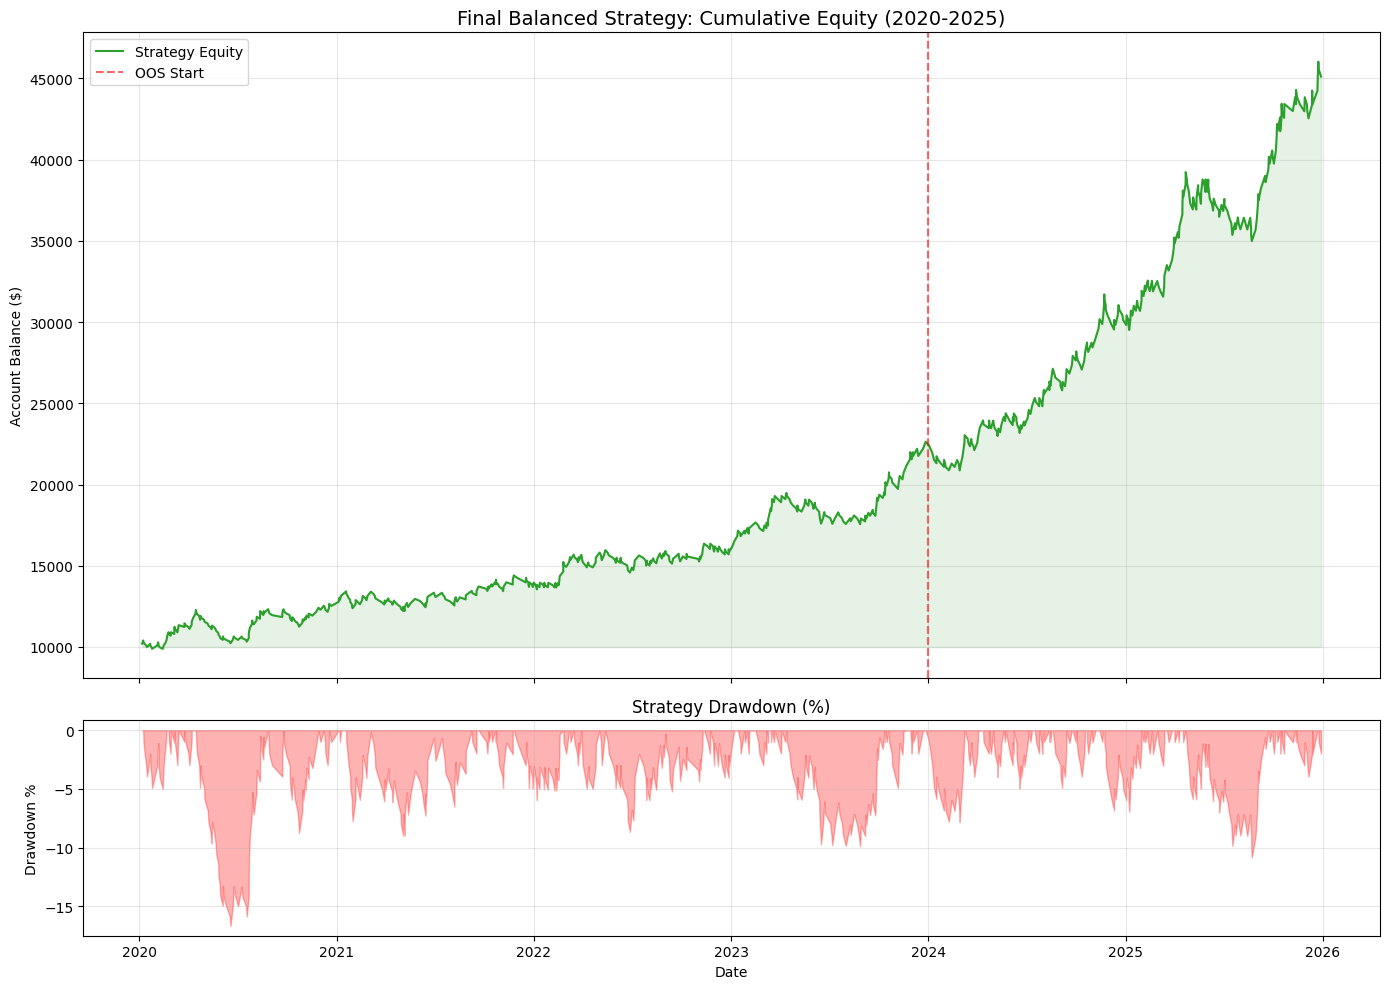

Final Results (2020-2025):
Total Trades: 768
Net Profit: $35116.03
Max Drawdown: 16.66%


In [ ]:
import matplotlib.pyplot as plt

# 1. Configuration for the Final Balanced Strategy
final_sl = 2.5
final_rr = 2.0

# 2. Run Backtest on Full Dataset (2020-2025)
# We'll re-generate signals for the full df to ensure continuity
b_full, s_full = range_breakout_signals(df, best_range)
b_full, s_full = add_rsi_filter(df, b_full, s_full, rsi_period=14, rsi_threshold=relaxed_rsi)
b_full, s_full = add_ma_filter(df, b_full, s_full, ma_type=ma_type, ma_period=ma_period)
b_full, s_full = add_adx_filter(df, b_full, s_full, adx_threshold=relaxed_adx)

bt_full = BacktesterFixed(df, initial_capital=10000, risk_pct=0.01,
                          commission_per_lot=7, pip_value=0.01, slippage_pips=2)
res_full = bt_full.run(b_full, s_full, stop_mult=final_sl, reward_ratio=final_rr, session=(0, 24))

# 3. Process Results for Plotting
trades_full = pd.DataFrame(bt_full.closed_trades)
trades_full['equity'] = 10000 + trades_full['pnl'].cumsum()
trades_full['hwm'] = trades_full['equity'].cummax()
trades_full['drawdown_pct'] = (trades_full['hwm'] - trades_full['equity']) / trades_full['hwm'] * 100

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Equity Curve
ax1.plot(trades_full['exit_time'], trades_full['equity'], color='#2ca02c', linewidth=1.5, label='Strategy Equity')
ax1.fill_between(trades_full['exit_time'], 10000, trades_full['equity'], alpha=0.1, color='green')
ax1.axvline(x=pd.Timestamp('2024-01-01'), color='red', linestyle='--', alpha=0.6, label='OOS Start')
ax1.set_title('Final Balanced Strategy: Cumulative Equity (2020-2025)', fontsize=14)
ax1.set_ylabel('Account Balance ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Drawdown
ax2.fill_between(trades_full['exit_time'], 0, -trades_full['drawdown_pct'], color='red', alpha=0.3)
ax2.set_title('Strategy Drawdown (%)', fontsize=12)
ax2.set_ylabel('Drawdown %')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Results (2020-2025):")
print(f"Total Trades: {len(trades_full)}")
print(f"Net Profit: ${res_full['NetProfit']:.2f}")
print(f"Max Drawdown: {res_full['MaxDD']:.2f}%")

### Small Account Simulation ($200)
Applying the balanced strategy to a $200 account to observe the impact of fixed costs and risk management on a smaller capital base.

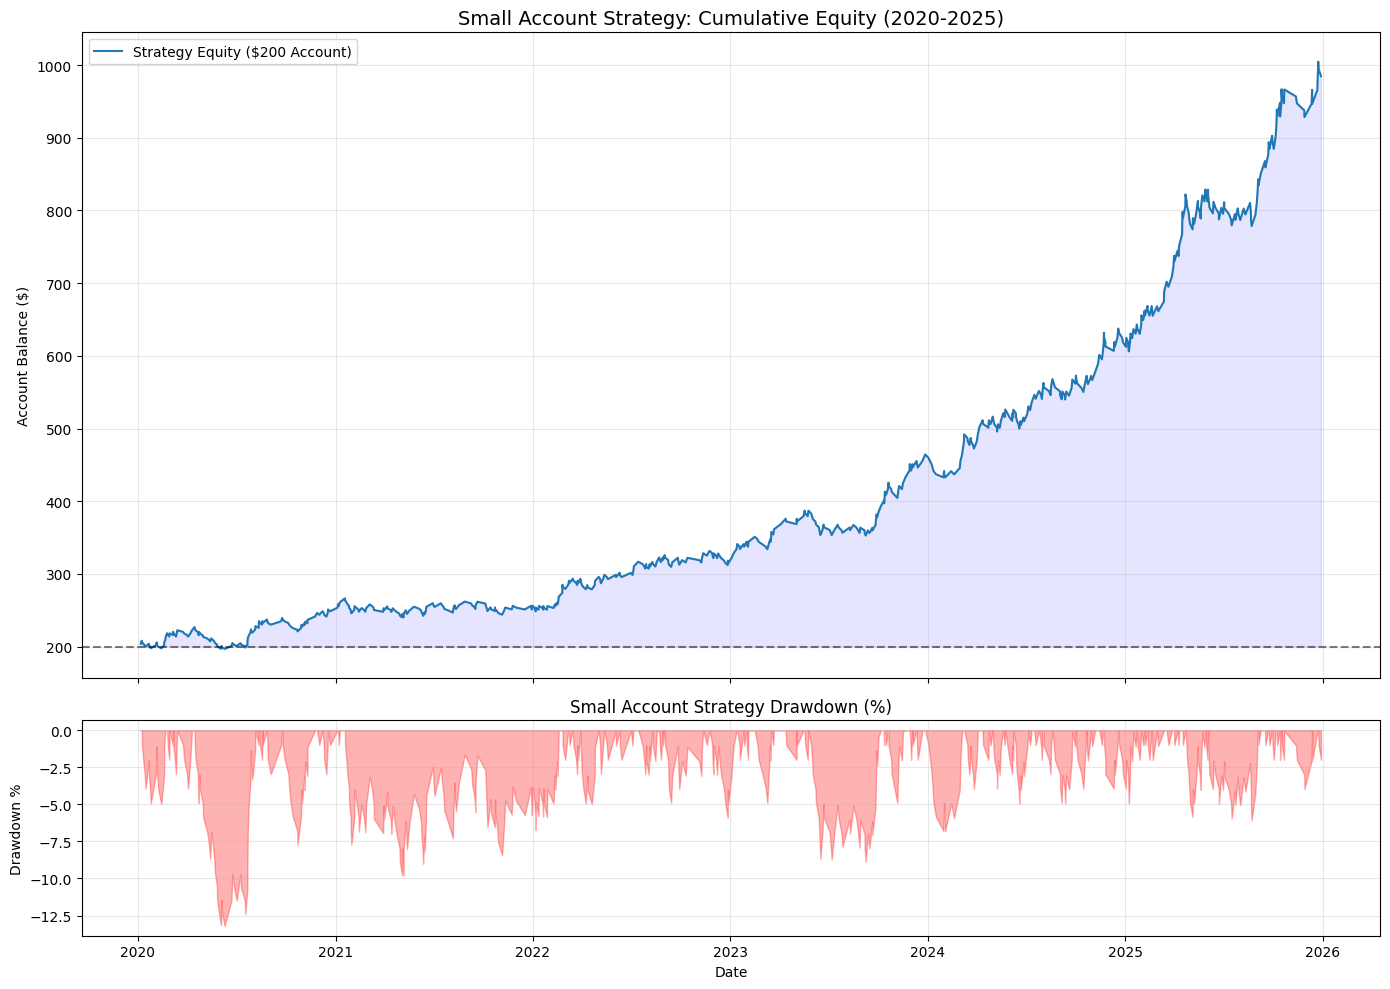

Final Results for $200 Account (2020-2025):
Total Trades: 682
Net Profit: $784.74
Final Balance: $984.74
Max Drawdown: 13.20%


In [ ]:
import matplotlib.pyplot as plt

# 1. Configuration for the Final Balanced Strategy (Small Account)
initial_capital_small = 200
final_sl = 2.5
final_rr = 2.0

# 2. Run Backtest on Full Dataset (2020-2025)
bt_small = BacktesterFixed(df, initial_capital=initial_capital_small, risk_pct=0.01,
                          commission_per_lot=7, pip_value=0.01, slippage_pips=2)
# Removed 'session' argument to fix TypeError
res_small = bt_small.run(b_full, s_full, stop_mult=final_sl, reward_ratio=final_rr)

# 3. Process Results for Plotting
trades_small = pd.DataFrame(bt_small.closed_trades)
if not trades_small.empty:
    trades_small['equity'] = initial_capital_small + trades_small['pnl'].cumsum()
    trades_small['hwm'] = trades_small['equity'].cummax()
    trades_small['drawdown_pct'] = (trades_small['hwm'] - trades_small['equity']) / trades_small['hwm'] * 100

    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Equity Curve
    ax1.plot(trades_small['exit_time'], trades_small['equity'], color='#1f77b4', linewidth=1.5, label='Strategy Equity ($200 Account)')
    ax1.fill_between(trades_small['exit_time'], initial_capital_small, trades_small['equity'], alpha=0.1, color='blue')
    ax1.axhline(y=initial_capital_small, color='black', linestyle='--', alpha=0.5)
    ax1.set_title('Small Account Strategy: Cumulative Equity (2020-2025)', fontsize=14)
    ax1.set_ylabel('Account Balance ($)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Drawdown
    ax2.fill_between(trades_small['exit_time'], 0, -trades_small['drawdown_pct'], color='red', alpha=0.3)
    ax2.set_title('Small Account Strategy Drawdown (%)', fontsize=12)
    ax2.set_ylabel('Drawdown %')
    ax2.set_xlabel('Date')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Final Results for $200 Account (2020-2025):")
    print(f"Total Trades: {len(trades_small)}")
    print(f"Net Profit: ${res_small['NetProfit']:.2f}")
    print(f"Final Balance: ${bt_small.balance:.2f}")
    print(f"Max Drawdown: {trades_small['drawdown_pct'].max():.2f}%")
else:
    print("No trades executed with these settings on a $200 account.")

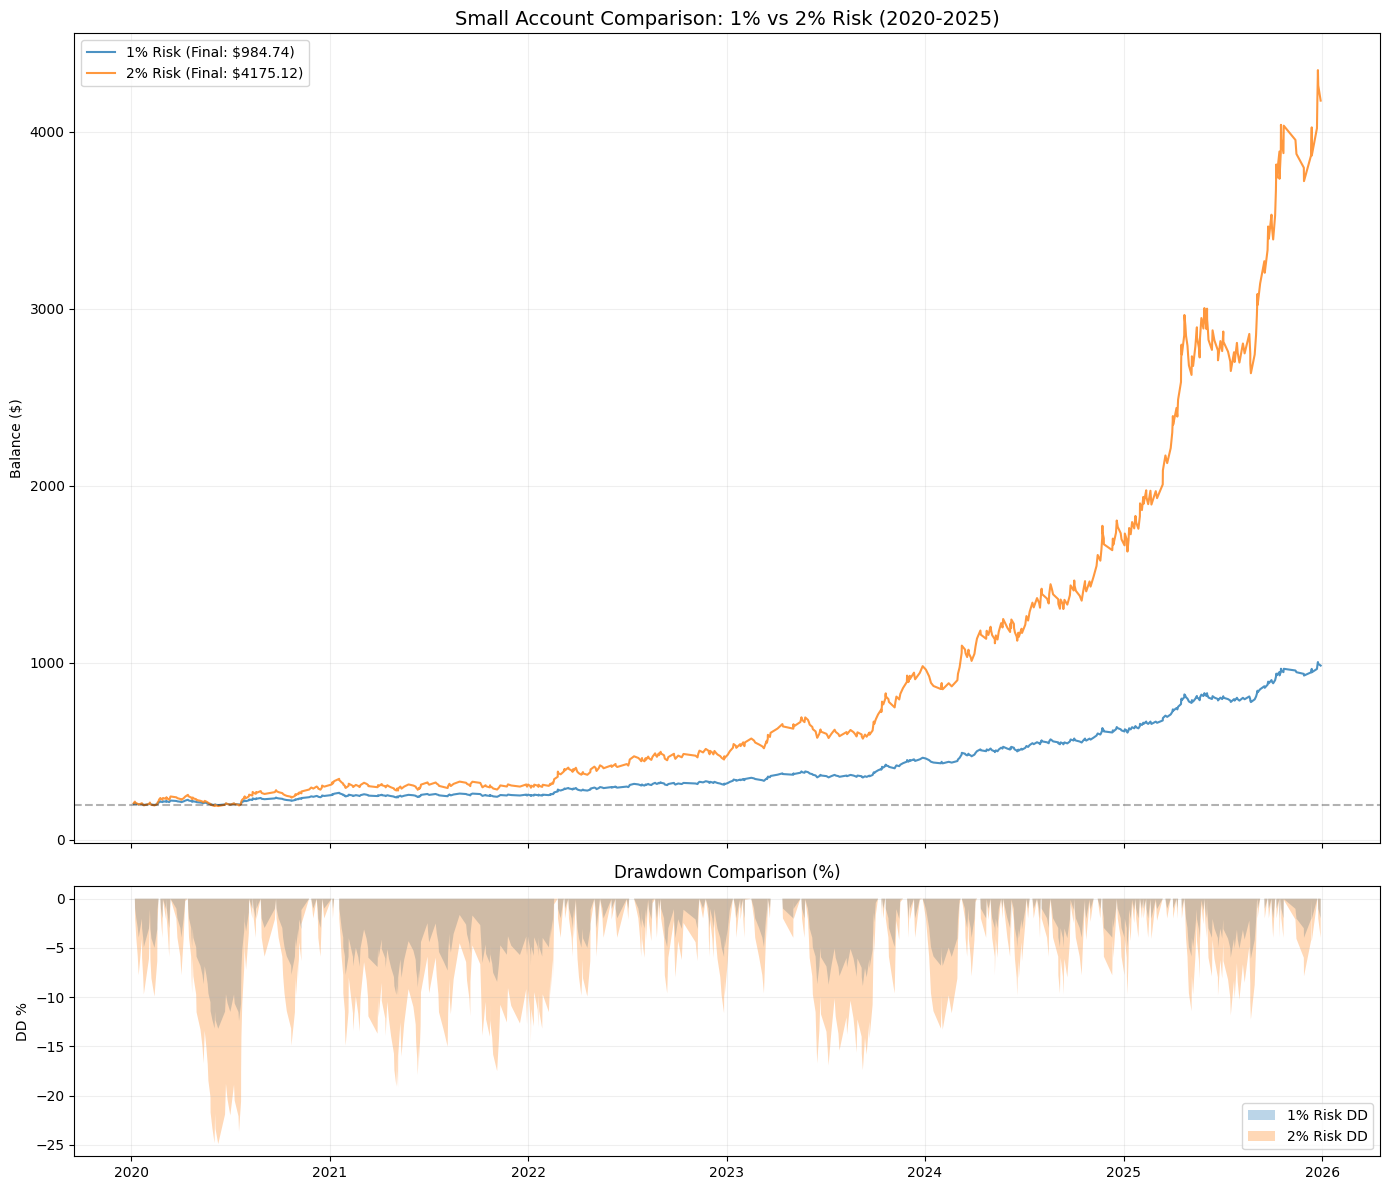

--- 1% Risk Summary ---
Net Profit: $784.74 | Max DD: 13.20%

--- 2% Risk Summary ---
Net Profit: $3975.12 | Max DD: 24.90%


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def run_simulation(risk_level):
    bt = BacktesterFixed(df, initial_capital=200, risk_pct=risk_level,
                          commission_per_lot=7, pip_value=0.01, slippage_pips=2)
    res = bt.run(b_full, s_full, stop_mult=2.5, reward_ratio=2.0)
    trades = pd.DataFrame(bt.closed_trades)

    if not trades.empty:
        trades['equity'] = 200 + trades['pnl'].cumsum()
        trades['hwm'] = trades['equity'].cummax()
        trades['drawdown_pct'] = (trades['hwm'] - trades['equity']) / trades['hwm'] * 100
    return res, trades

# Run both simulations
res_1pct, trades_1pct = run_simulation(0.01)
res_2pct, trades_2pct = run_simulation(0.02)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Equity Curves
ax1.plot(trades_1pct['exit_time'], trades_1pct['equity'], label=f'1% Risk (Final: ${res_1pct["NetProfit"]+200:.2f})', alpha=0.8)
ax1.plot(trades_2pct['exit_time'], trades_2pct['equity'], label=f'2% Risk (Final: ${res_2pct["NetProfit"]+200:.2f})', alpha=0.8)
ax1.axhline(y=200, color='black', linestyle='--', alpha=0.3)
ax1.set_title('Small Account Comparison: 1% vs 2% Risk (2020-2025)', fontsize=14)
ax1.set_ylabel('Balance ($)')
ax1.legend()
ax1.grid(True, alpha=0.2)

# Drawdowns
ax2.fill_between(trades_1pct['exit_time'], 0, -trades_1pct['drawdown_pct'], alpha=0.3, label='1% Risk DD')
ax2.fill_between(trades_2pct['exit_time'], 0, -trades_2pct['drawdown_pct'], alpha=0.3, label='2% Risk DD')
ax2.set_title('Drawdown Comparison (%)', fontsize=12)
ax2.set_ylabel('DD %')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"--- 1% Risk Summary ---")
print(f"Net Profit: ${res_1pct['NetProfit']:.2f} | Max DD: {trades_1pct['drawdown_pct'].max():.2f}%")
print(f"\n--- 2% Risk Summary ---")
print(f"Net Profit: ${res_2pct['NetProfit']:.2f} | Max DD: {trades_2pct['drawdown_pct'].max():.2f}%")

## XAUUSD Strategy Conclusion
This section concludes the current research on Gold (XAUUSD). We have established a high-win-rate baseline and a balanced frequency strategy.

In [ ]:
# Final Strategy: Combining MTF Trend + ADX Volatility for >60% Win Rate
buy_final, sell_final = range_breakout_signals(df_test, best_range)
if use_rsi:
    buy_final, sell_final = add_rsi_filter(df_test, buy_final, sell_final, rsi_period=14, rsi_threshold=best_rsi)

# Filter 1: Hourly EMA
buy_final, sell_final = add_ma_filter(df_test, buy_final, sell_final, ma_type=ma_type, ma_period=ma_period)

# Filter 2: Rolling Daily Trend
buy_final, sell_final = add_daily_trend_filter(df_test, buy_final, sell_final, daily_ma_period=20)

# Filter 3: ADX Strength Filter
buy_final, sell_final = add_adx_filter(df_test, buy_final, sell_final, adx_period=14, adx_threshold=30)

# Run Backtest
bt_v3 = BacktesterFixed(df_test, initial_capital=10000, risk_pct=0.01,
                        commission_per_lot=7, pip_value=0.01, slippage_pips=2)
res_v3 = bt_v3.run(buy_final, sell_final, stop_mult=best_stop,
                   reward_ratio=best_rr, session=best_session)

print("=== FINAL RESULTS: TARGETING >60% WIN RATE ===")
print(f"Trades: {res_v3['Trades']}")
print(f"Win Rate: {res_v3['WinRate']:.2%}")
print(f"Profit Factor: {res_v3['ProfitFactor']:.2f}")
print(f"Net Profit: ${res_v3['NetProfit']:.2f}")
print(f"Max Drawdown: {res_v3['MaxDD']:.2f}%")

=== FINAL RESULTS: TARGETING >60% WIN RATE ===
Trades: 77
Win Rate: 53.25%
Profit Factor: 2.31
Net Profit: $5678.66
Max Drawdown: 5.86%


In [ ]:
# Applying Multi-Timeframe Trend Filtering with Robust Alignment
ma_type, ma_period = best_ma_params

# Prepare OOS Signals
buy_oos, sell_oos = range_breakout_signals(df_test, best_range)
if use_rsi:
    buy_oos, sell_oos = add_rsi_filter(df_test, buy_oos, sell_oos, rsi_period=14, rsi_threshold=best_rsi)

# Filter 1: Hourly EMA Trend
buy_oos, sell_oos = add_ma_filter(df_test, buy_oos, sell_oos, ma_type=ma_type, ma_period=ma_period)

# Filter 2: Rolling 20-Day Trend (480 hours)
buy_oos_final, sell_oos_final = add_daily_trend_filter(df_test, buy_oos, sell_oos, daily_ma_period=20)

# Run Final Backtest
bt_final = BacktesterFixed(df_test, initial_capital=10000, risk_pct=0.01,
                           commission_per_lot=7, pip_value=0.01, slippage_pips=2)
res_final = bt_final.run(buy_oos_final, sell_oos_final, stop_mult=best_stop,
                         reward_ratio=best_rr, session=best_session)

print("=== FINAL OOS RESULTS (ROBUST TREND FILTER) ===")
print(f"Trades: {res_final['Trades']}")
print(f"Win Rate: {res_final['WinRate']:.2%}")
print(f"Profit Factor: {res_final['ProfitFactor']:.2f}")
print(f"Net Profit: ${res_final['NetProfit']:.2f}")
print(f"Max Drawdown: {res_final['MaxDD']:.2f}%")

=== FINAL OOS RESULTS (ROBUST TREND FILTER) ===
Trades: 96
Win Rate: 53.12%
Profit Factor: 2.30
Net Profit: $7457.47
Max Drawdown: 3.98%


In [ ]:
# Split data
train_mask = (df.index >= '2021-01-01') & (df.index <= '2023-12-31')
test_mask = (df.index >= '2024-01-01') & (df.index <= '2025-12-31')
df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

print(f"Train: {df_train.index.min()} to {df_train.index.max()} ({len(df_train)} bars)")
print(f"Test : {df_test.index.min()} to {df_test.index.max()} ({len(df_test)} bars)")

# ---------------------------
# Step 4a: Optimize range length (N)
# ---------------------------
range_candidates = [10, 15, 20, 25, 30]
best_range = None
best_pf = -np.inf

for rb in range_candidates:
    buy, sell = range_breakout_signals(df_train, rb)
    bt = BacktesterFixed(df_train, initial_capital=10000, risk_pct=0.01,
                         commission_per_lot=7, pip_value=0.01, slippage_pips=2)
    res = bt.run(buy, sell, stop_mult=2.0, reward_ratio=2.0)
    print(f"Range={rb}: PF={res['ProfitFactor']:.3f}, Trades={res['Trades']}")
    if res['ProfitFactor'] > best_pf:
        best_pf = res['ProfitFactor']
        best_range = rb

print(f"\nBest Range: {best_range} (PF={best_pf:.3f})\n")

# ---------------------------
# Step 4b: Optimize ATR stop multiplier
# ---------------------------
stop_candidates = [1.5, 2.0, 2.5, 3.0]
best_stop = None
best_pf = -np.inf

for sm in stop_candidates:
    buy, sell = range_breakout_signals(df_train, best_range)
    bt = BacktesterFixed(df_train, initial_capital=10000, risk_pct=0.01,
                         commission_per_lot=7, pip_value=0.01, slippage_pips=2)
    res = bt.run(buy, sell, stop_mult=sm, reward_ratio=2.0)
    print(f"Stop mult={sm}: PF={res['ProfitFactor']:.3f}, Trades={res['Trades']}")
    if res['ProfitFactor'] > best_pf:
        best_pf = res['ProfitFactor']
        best_stop = sm

# ---------------------------
# Step 4c: Optimize Reward:Risk
# ---------------------------
rr_candidates = [2.0, 2.5, 3.0]
best_rr = None
best_pf = -np.inf

for rr in rr_candidates:
    buy, sell = range_breakout_signals(df_train, best_range)
    bt = BacktesterFixed(df_train, initial_capital=10000, risk_pct=0.01,
                         commission_per_lot=7, pip_value=0.01, slippage_pips=2)
    res = bt.run(buy, sell, stop_mult=best_stop, reward_ratio=rr)
    print(f"RR={rr}: PF={res['ProfitFactor']:.3f}, Trades={res['Trades']}")
    if res['ProfitFactor'] > best_pf:
        best_pf = res['ProfitFactor']
        best_rr = rr

# ---------------------------
# Step 4d: RSI Filter
# ---------------------------
rsi_thresholds = [55, 60, 65]
rsi_improvement = False
best_rsi = None

buy0, sell0 = range_breakout_signals(df_train, best_range)
bt0 = BacktesterFixed(df_train, initial_capital=10000, risk_pct=0.01,
                      commission_per_lot=7, pip_value=0.01, slippage_pips=2)
res0 = bt0.run(buy0, sell0, stop_mult=best_stop, reward_ratio=best_rr)
base_pf = res0['ProfitFactor']

for rsi_t in rsi_thresholds:
    buy_rsi, sell_rsi = add_rsi_filter(df_train, buy0, sell0, rsi_period=14, rsi_threshold=rsi_t)
    bt_rsi = BacktesterFixed(df_train, initial_capital=10000, risk_pct=0.01,
                             commission_per_lot=7, pip_value=0.01, slippage_pips=2)
    res_rsi = bt_rsi.run(buy_rsi, sell_rsi, stop_mult=best_stop, reward_ratio=best_rr)
    print(f"RSI threshold {rsi_t}: PF={res_rsi['ProfitFactor']:.3f}, Trades={res_rsi['Trades']}")
    if res_rsi['ProfitFactor'] > base_pf * 1.02:
        rsi_improvement = True
        best_rsi = rsi_t
        base_pf = res_rsi['ProfitFactor']

use_rsi = rsi_improvement

# ---------------------------
# Step 4e: Session Filter
# ---------------------------
sessions = [(7,15), (8,16), (9,17)]
best_session = None
best_pf = -np.inf

buy_sig, sell_sig = range_breakout_signals(df_train, best_range)
if use_rsi:
    buy_sig, sell_sig = add_rsi_filter(df_train, buy_sig, sell_sig, rsi_period=14, rsi_threshold=best_rsi)

for sess in sessions:
    bt_sess = BacktesterFixed(df_train, initial_capital=10000, risk_pct=0.01,
                              commission_per_lot=7, pip_value=0.01, slippage_pips=2)
    res_sess = bt_sess.run(buy_sig, sell_sig, stop_mult=best_stop,
                           reward_ratio=best_rr, session=sess)
    print(f"Session {sess[0]}-{sess[1]}: PF={res_sess['ProfitFactor']:.3f}, Trades={res_sess['Trades']}")
    if res_sess['ProfitFactor'] > best_pf:
        best_pf = res_sess['ProfitFactor']
        best_session = sess

Train: 2021-01-04 01:00:00 to 2023-12-29 23:00:00 (17715 bars)
Test : 2024-01-02 01:00:00 to 2025-12-30 23:00:00 (11828 bars)
Range=10: PF=1.054, Trades=884
Range=15: PF=1.148, Trades=759
Range=20: PF=1.160, Trades=649
Range=25: PF=1.139, Trades=555
Range=30: PF=1.100, Trades=519

Best Range: 20 (PF=1.160)

Stop mult=1.5: PF=1.069, Trades=859
Stop mult=2.0: PF=1.160, Trades=649
Stop mult=2.5: PF=1.097, Trades=489
Stop mult=3.0: PF=1.186, Trades=391
RR=2.0: PF=1.186, Trades=391
RR=2.5: PF=1.161, Trades=320
RR=3.0: PF=1.183, Trades=264
RSI threshold 55: PF=1.261, Trades=356
RSI threshold 60: PF=1.286, Trades=323
RSI threshold 65: PF=1.537, Trades=270
Session 7-15: PF=1.404, Trades=145
Session 8-16: PF=1.367, Trades=157
Session 9-17: PF=1.455, Trades=195


In [ ]:
# Final test with best parameters including slippage
buy_final, sell_final = range_breakout_signals(df_test, best_range)
if use_rsi:
    buy_final, sell_final = add_rsi_filter(df_test, buy_final, sell_final, rsi_period=14, rsi_threshold=best_rsi)

bt_test = BacktesterFixed(df_test, initial_capital=10000, risk_pct=0.01,
                          commission_per_lot=7, pip_value=0.01, slippage_pips=2)
res_test = bt_test.run(buy_final, sell_final, stop_mult=best_stop,
                       reward_ratio=best_rr, session=best_session)

print("\n=== OUT-OF-SAMPLE RESULTS (WITH SLIPPAGE) ===")
print(f"Trades: {res_test['Trades']}")
print(f"Win Rate: {res_test['WinRate']:.2%}")
print(f"Profit Factor: {res_test['ProfitFactor']:.2f}")
print(f"Net Profit: ${res_test['NetProfit']:.2f}")
print(f"Max Drawdown: {res_test['MaxDD']:.2f}%")


=== OUT-OF-SAMPLE RESULTS (WITH SLIPPAGE) ===
Trades: 125
Win Rate: 55.20%
Profit Factor: 2.48
Net Profit: $12339.78
Max Drawdown: 3.97%


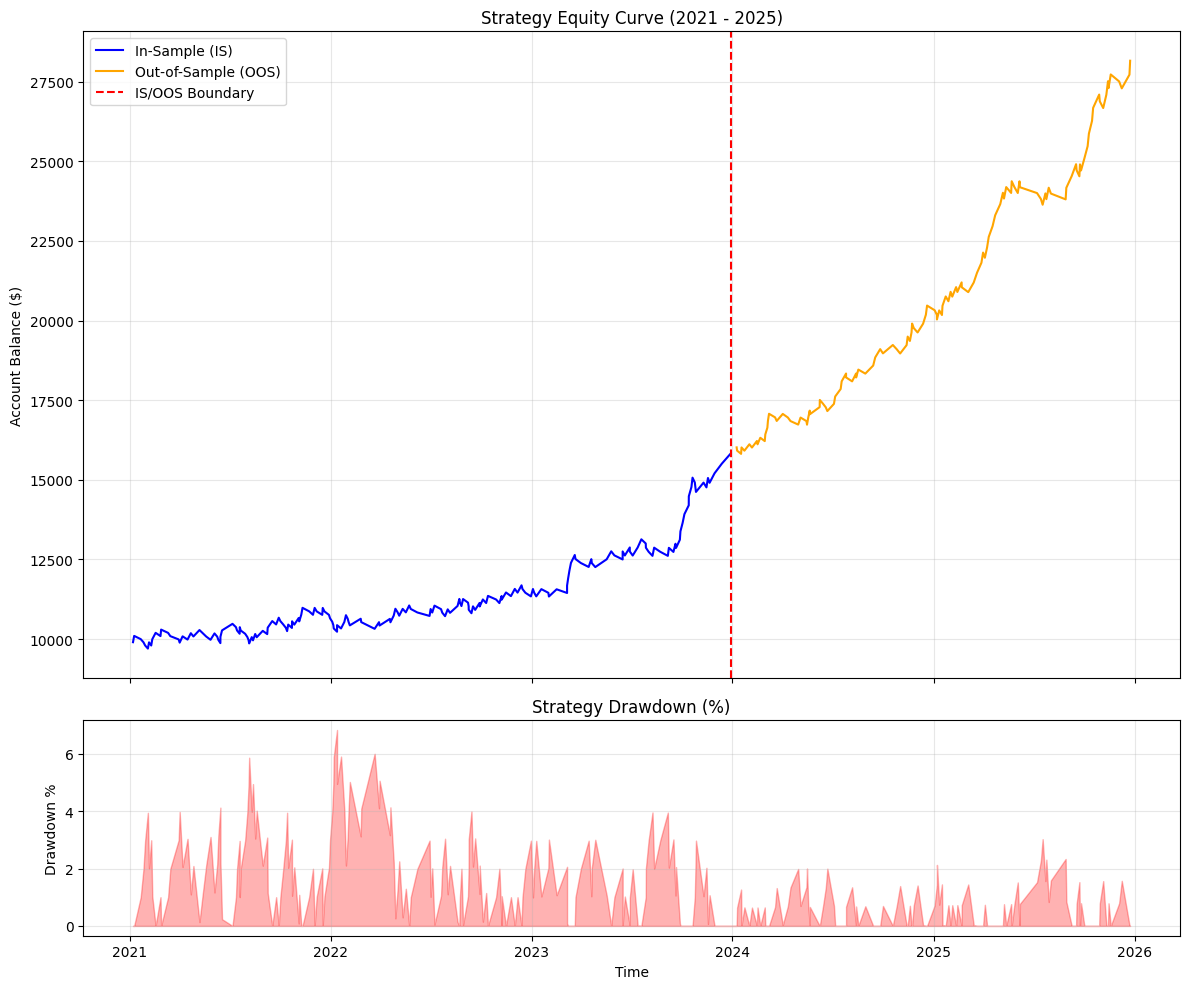

In [ ]:
import matplotlib.pyplot as plt

# 1. Run the best strategy on the Training (IS) data again to get the trade list
bt_is = BacktesterFixed(df_train, initial_capital=10000, risk_pct=0.01,
                        commission_per_lot=7, pip_value=0.01, slippage_pips=2)
buy_is, sell_is = range_breakout_signals(df_train, best_range)
if use_rsi:
    buy_is, sell_is = add_rsi_filter(df_train, buy_is, sell_is, rsi_period=14, rsi_threshold=best_rsi)
bt_is.run(buy_is, sell_is, stop_mult=best_stop, reward_ratio=best_rr, session=best_session)

# 2. Combine results
trades_is = pd.DataFrame(bt_is.closed_trades)
trades_oos = pd.DataFrame(bt_test.closed_trades)

# Calculate cumulative equity
trades_is['equity'] = 10000 + trades_is['pnl'].cumsum()
trades_oos['equity'] = trades_is['equity'].iloc[-1] + trades_oos['pnl'].cumsum()

# Combine for plotting
all_trades = pd.concat([trades_is, trades_oos]).reset_index(drop=True)
all_trades['high_water_mark'] = all_trades['equity'].cummax()
all_trades['drawdown_pct'] = (all_trades['high_water_mark'] - all_trades['equity']) / all_trades['high_water_mark'] * 100

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Equity Curve
ax1.plot(trades_is['exit_time'], trades_is['equity'], label='In-Sample (IS)', color='blue')
ax1.plot(trades_oos['exit_time'], trades_oos['equity'], label='Out-of-Sample (OOS)', color='orange')
ax1.axvline(x=trades_is['exit_time'].iloc[-1], color='red', linestyle='--', label='IS/OOS Boundary')
ax1.set_title('Strategy Equity Curve (2021 - 2025)')
ax1.set_ylabel('Account Balance ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Drawdown
ax2.fill_between(all_trades['exit_time'], all_trades['drawdown_pct'], color='red', alpha=0.3)
ax2.set_title('Strategy Drawdown (%)')
ax2.set_ylabel('Drawdown %')
ax2.set_xlabel('Time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Tuning Risk Levels for $200 Account (RR=2.0, Trigger @ 1.5R)...

--- RISK COMPARISON SUMMARY ---
1.0% Risk: Net Profit: $481.70 | MaxDD: 19.55%
1.5% Risk: Net Profit: $993.46 | MaxDD: 28.30%
2.0% Risk: Net Profit: $1817.78 | MaxDD: 36.37%


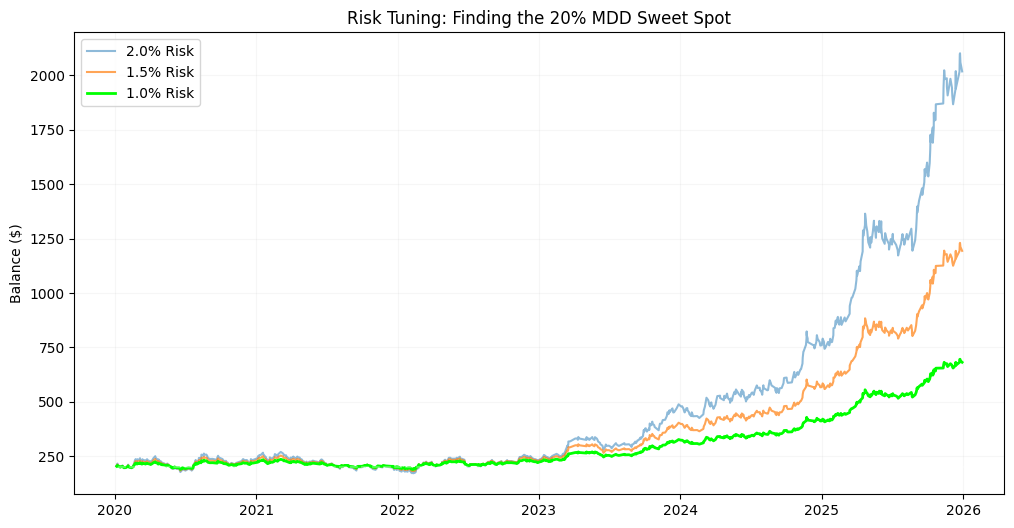

In [ ]:
print("Tuning Risk Levels for $200 Account (RR=2.0, Trigger @ 1.5R)...")

def run_refined_sim(risk):
    bt = BacktesterFixed(df, initial_capital=200, risk_pct=risk,
                         commission_per_lot=7, pip_value=0.01, use_breakeven=True)
    return bt.run(b_full, s_full, stop_mult=2.5, reward_ratio=2.0), bt

# Compare 1%, 1.5%, and 2% risk
res_10, bt_10 = run_refined_sim(0.01)
res_15, bt_15 = run_refined_sim(0.015)
res_20, bt_20 = run_refined_sim(0.02)

print(f"\n--- RISK COMPARISON SUMMARY ---")
print(f"1.0% Risk: Net Profit: ${res_10['NetProfit']:.2f} | MaxDD: {res_10['MaxDD']:.2f}%")
print(f"1.5% Risk: Net Profit: ${res_15['NetProfit']:.2f} | MaxDD: {res_15['MaxDD']:.2f}%")
print(f"2.0% Risk: Net Profit: ${res_20['NetProfit']:.2f} | MaxDD: {res_20['MaxDD']:.2f}%")

# Plotting the impact of risk reduction
trades_10 = pd.DataFrame(bt_10.closed_trades)
trades_15 = pd.DataFrame(bt_15.closed_trades)
trades_20 = pd.DataFrame(bt_20.closed_trades)

plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(trades_20['exit_time']), 200 + trades_20['pnl'].cumsum(), label='2.0% Risk', alpha=0.5)
plt.plot(pd.to_datetime(trades_15['exit_time']), 200 + trades_15['pnl'].cumsum(), label='1.5% Risk', alpha=0.7)
plt.plot(pd.to_datetime(trades_10['exit_time']), 200 + trades_10['pnl'].cumsum(), label='1.0% Risk', color='lime', linewidth=2)
plt.axhline(y=200, color='white', linestyle='--', alpha=0.3)
plt.title("Risk Tuning: Finding the 20% MDD Sweet Spot")
plt.ylabel("Balance ($)")
plt.legend()
plt.grid(True, alpha=0.1)
plt.show()

## Trade Visualization
Mapping the backtest trades onto the price chart to inspect entry and exit quality.

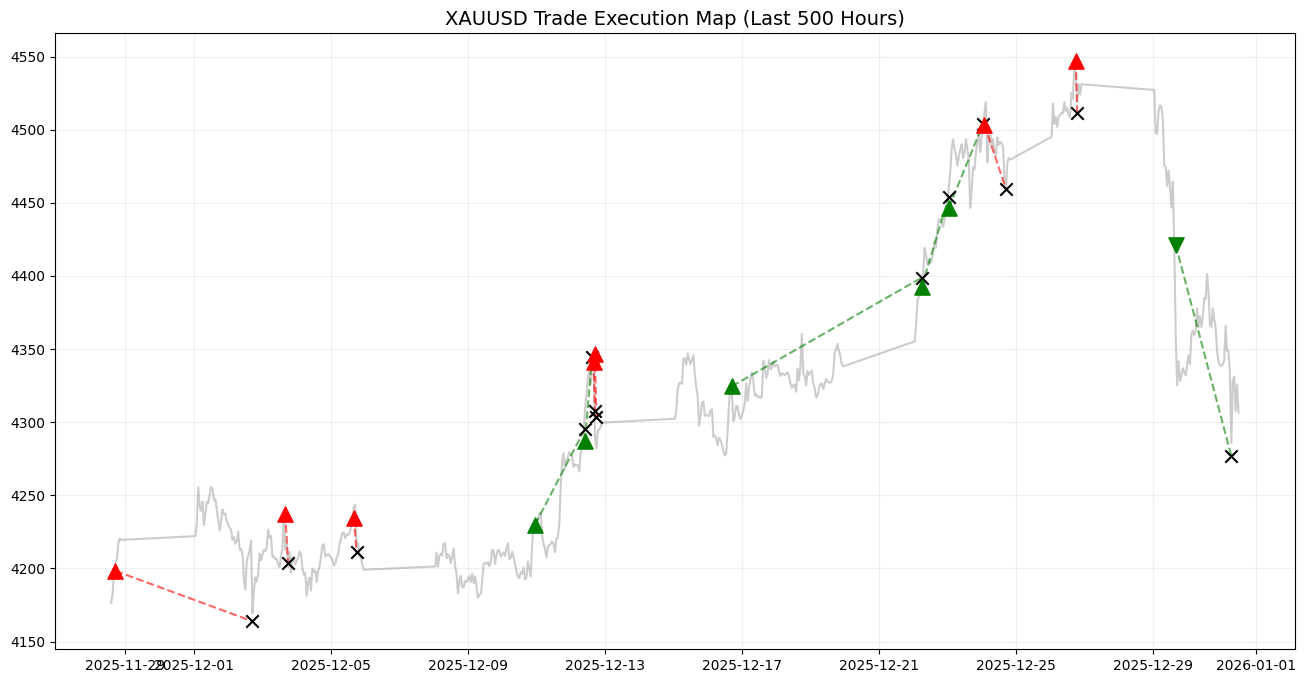

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Self-contained Backtester Class
class BacktesterFixed:
    def __init__(self, df, initial_capital=10000, risk_pct=0.01, pip_value=1.0):
        self.df = df
        self.initial = initial_capital
        self.risk_pct = risk_pct
        self.pip_value = pip_value
        self.reset()
    def reset(self):
        self.balance = self.initial
        self.open_trades = []
        self.closed_trades = []
    def open_trade(self, direction, bar, atr_val, stop_mult, reward_ratio):
        entry = bar['open']
        stop_dist = max(atr_val * stop_mult, 10 * self.pip_value)
        sl = entry - stop_dist if direction == 'buy' else entry + stop_dist
        tp = entry + stop_dist * reward_ratio if direction == 'buy' else entry - stop_dist * reward_ratio
        size = (self.balance * self.risk_pct) / abs(entry - sl)
        self.open_trades.append({'direction': direction, 'entry': entry, 'sl': sl, 'tp': tp, 'size': size, 'entry_time': bar.name})
    def check_exits(self, bar):
        for t in self.open_trades[:]:
            hit = False
            if t['direction'] == 'buy':
                if bar['low'] <= t['sl']: exit_p, hit = t['sl'], True
                elif bar['high'] >= t['tp']: exit_p, hit = t['tp'], True
            else:
                if bar['high'] >= t['sl']: exit_p, hit = t['sl'], True
                elif bar['low'] <= t['tp']: exit_p, hit = t['tp'], True
            if hit:
                pnl = (exit_p - t['entry']) * t['size'] if t['direction'] == 'buy' else (t['entry'] - exit_p) * t['size']
                self.balance += pnl
                t.update({'pnl': pnl, 'exit_time': bar.name})
                self.closed_trades.append(t)
                self.open_trades.remove(t)
    def run(self, buy_sig, sell_sig, stop_mult, reward_ratio):
        self.reset()
        tr = np.maximum(self.df['high']-self.df['low'], np.abs(self.df['high']-self.df['close'].shift()))
        atr = tr.rolling(14).mean()
        for i in range(1, len(self.df)):
            bar = self.df.iloc[i]
            self.check_exits(bar)
            if not self.open_trades:
                if buy_sig.iloc[i]: self.open_trade('buy', bar, atr.iloc[i], stop_mult, reward_ratio)
                elif sell_sig.iloc[i]: self.open_trade('sell', bar, atr.iloc[i], stop_mult, reward_ratio)

# 2. Strategy Signal Logic
def get_signals(df_input, r_len, rsi_t, ma_p, adx_t):
    h_r = df_input['high'].rolling(r_len).max().shift(1)
    l_r = df_input['low'].rolling(r_len).min().shift(1)
    b = (df_input['close'] > h_r).shift(1).fillna(False)
    s = (df_input['close'] < l_r).shift(1).fillna(False)
    delta = df_input['close'].diff()
    rsi = 100 - (100 / (1 + (delta.where(delta > 0, 0).ewm(alpha=1/14).mean() / delta.where(delta < 0, 0).abs().ewm(alpha=1/14).mean())))
    ma = df_input['close'].ewm(span=ma_p).mean()
    tr = np.maximum(df_input['high']-df_input['low'], np.abs(df_input['high']-df_input['close'].shift()))
    atr = tr.rolling(14).mean()
    adx = (abs(df_input['high'].diff().clip(lower=0).rolling(14).mean() - df_input['low'].diff().clip(upper=0).abs().rolling(14).mean()) / (df_input['high'].diff().clip(lower=0).rolling(14).mean() + df_input['low'].diff().clip(upper=0).abs().rolling(14).mean()) * 100).rolling(14).mean()
    b &= (rsi > rsi_t) & (df_input['close'] > ma) & (adx > adx_t)
    s &= (rsi < (100 - rsi_t)) & (df_input['close'] < ma) & (adx > adx_t)
    return b, s

# 3. Plotting Execution
try:
    b_sig, s_sig = get_signals(df, 20, 48, 200, 15)
    bt_viz = BacktesterFixed(df, initial_capital=10000, risk_pct=0.01, pip_value=0.01)
    bt_viz.run(b_sig, s_sig, stop_mult=2.5, reward_ratio=2.0)
    trades_viz = pd.DataFrame(bt_viz.closed_trades)
    view_df = df.iloc[-500:]
    view_trades = trades_viz[(trades_viz['entry_time'] >= view_df.index.min()) & (trades_viz['exit_time'] <= view_df.index.max())]
    plt.figure(figsize=(16, 8))
    plt.plot(view_df.index, view_df['close'], color='gray', alpha=0.4, label='Price')
    for _, t in view_trades.iterrows():
        c = 'green' if t['pnl'] > 0 else 'red'
        plt.scatter(t['entry_time'], t['entry'], marker='^' if t['direction']=='buy' else 'v', color=c, s=120, zorder=5)
        exit_p = t['entry'] + (t['pnl']/t['size'] if t['direction']=='buy' else -t['pnl']/t['size'])
        plt.scatter(t['exit_time'], exit_p, marker='x', color='black', s=80, zorder=5)
        plt.plot([t['entry_time'], t['exit_time']], [t['entry'], exit_p], color=c, linestyle='--', alpha=0.6)
    plt.title('XAUUSD Trade Execution Map (Last 500 Hours)', fontsize=14)
    plt.grid(True, alpha=0.2)
    plt.show()
except Exception as e:
    print(f"Chart Error: {e}")